# Next Word Predictor - Final Project Notebook

**Author:** Disha Janardhan

## Overview

This final notebook extends the Week 5 and Week 7 checkpoints into a more complete final-project pipeline:

1. **Baselines** - unigram-frequency and bigram-Markov baselines (the real reference points; uniform-random over 9k classes is misleading).
2. **Fine-tune models** - regularization tuning for Logistic Regression (BoW + TF-IDF), the MLP, and Random Forest.
3. **Held-out test evaluation** - Top-1/3/5 with bootstrap CIs, all model families on the SAME 10k test subset for fairness.
4. **Error analysis** + context-length / vocab-size ablations with per-setting regularization.

Notes:
- Book-level 70/15/15 split. `label_encoder` is fit on **train targets only**; val/test targets unseen in train are tracked via `unseen_target_rate`.
- Sample budget + grids are sized to finish end-to-end in a reasonable time.


## Section 1 - Setup and Imports

In [26]:
import os
import re
import json
import math
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, log_loss

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEFAULT_WINDOW = 4
DEFAULT_TOP_N_VOCAB = 10_000
DEFAULT_MAX_SAMPLES = 80_000      # was 500k -- shrunk so the full pipeline runs end-to-end
LR_TRAIN_EVAL_SUBSET = 3_000
MLP_TRAIN_EVAL_SUBSET = 2_000
RF_TRAIN_SUBSET = 8_000
RF_VAL_SUBSET = 3_000
FINAL_RF_TRAIN_SUBSET = 20_000
SHARED_TEST_SUBSET_CAP = 3_000
BOOTSTRAP_SAMPLES = 100
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

os.makedirs('outputs/figures', exist_ok=True)

print('Setup complete.')


Setup complete.


## Section 2 - Load Vocabulary and Clean Book Texts

In [27]:
with open('data/processed/vocab.json', 'r') as f:
    word2idx = json.load(f)

BOOK_IDS = [
    1342, 11, 84, 1661, 2701, 98, 1400, 46, 76, 74,
    345, 1260, 768, 2554, 2600, 1080, 5200, 174, 244, 1232,
    2814, 4300, 16, 43, 120, 35, 36, 5230, 158, 161,
    105, 730, 3207, 7370, 61, 2265, 1514, 1522, 1513, 2641,
    2148, 600, 1184, 514, 1952, 3825, 1251, 23, 2097, 3296,
]

START_RE = re.compile(r'\*{3}\s*START OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)
END_RE   = re.compile(r'\*{3}\s*END OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)

def strip_gutenberg_boilerplate(text):
    start_match = START_RE.search(text)
    end_match = END_RE.search(text)
    if start_match and end_match:
        return text[start_match.end():end_match.start()]
    if start_match:
        return text[start_match.end():]
    return text


def clean_text(text):
    text = strip_gutenberg_boilerplate(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def map_token(tok):
    return tok if tok in word2idx else '<UNK>'


cleaned_books = {}
downloaded = []
for bid in BOOK_IDS:
    path = f'data/raw/{bid}.txt'
    if os.path.exists(path):
        raw = open(path, encoding='utf-8', errors='replace').read()
        cleaned_books[bid] = clean_text(raw)
        downloaded.append(bid)

print(f'Books loaded: {len(downloaded)} / {len(BOOK_IDS)}')
print(f'Vocabulary size (incl. <UNK>): {len(word2idx):,}')

Books loaded: 50 / 50
Vocabulary size (incl. <UNK>): 10,001


## Section 3 - Split Books into Train, Validation, and Test Sets

The split happens at the **book level** rather than the sample level. This is stricter than a random sliding-window split and better matches the final project goal of evaluating generalization to unseen books.

In [28]:
def split_books(book_ids, train_frac=0.70, val_frac=0.15, seed=42):
    rng = random.Random(seed)
    shuffled = list(book_ids)
    rng.shuffle(shuffled)

    n_total = len(shuffled)
    n_train = max(1, round(train_frac * n_total))
    n_val = max(1, round(val_frac * n_total))
    n_test = n_total - n_train - n_val

    if n_test < 1:
        n_test = 1
        n_train = max(1, n_train - 1)

    train_books = shuffled[:n_train]
    val_books = shuffled[n_train:n_train + n_val]
    test_books = shuffled[n_train + n_val:]
    return train_books, val_books, test_books


train_books, val_books, test_books = split_books(downloaded, TRAIN_FRAC, VAL_FRAC, RANDOM_SEED)

print(f'Train books ({len(train_books)}): {sorted(train_books)}')
print(f'Val books   ({len(val_books)}): {sorted(val_books)}')
print(f'Test books  ({len(test_books)}): {sorted(test_books)}')

Train books (35): [16, 35, 36, 43, 74, 105, 120, 158, 161, 244, 345, 514, 600, 730, 768, 1184, 1232, 1251, 1260, 1342, 1513, 1514, 1661, 1952, 2097, 2265, 2554, 2641, 2701, 2814, 3207, 3825, 4300, 5200, 7370]
Val books   (8): [23, 61, 84, 98, 1400, 1522, 3296, 5230]
Test books  (7): [11, 46, 76, 174, 1080, 2148, 2600]


## Section 4 - Sample Generation and Evaluation Helpers

In [29]:
def generate_samples_for_books(cleaned_books, selected_books, window_size, max_samples=200_000):
    """Sliding-window samples, capped per book to keep splits balanced."""
    per_book_cap = max(1, max_samples // max(1, len(selected_books)))
    contexts, targets, book_ids = [], [], []
    for bid in selected_books:
        tokens = cleaned_books[bid].split()
        mapped = [map_token(tok) for tok in tokens]
        book_count = 0
        for i in range(len(mapped) - window_size):
            target = mapped[i + window_size]
            if target == '<UNK>':
                continue
            contexts.append(mapped[i:i + window_size])
            targets.append(target)
            book_ids.append(bid)
            book_count += 1
            if book_count >= per_book_cap:
                break
    return contexts, targets, book_ids


# Generate once at the default window, then split — avoids regenerating the
# same samples inside every build_split_dataset call.
all_contexts, all_targets, all_sample_books = generate_samples_for_books(
    cleaned_books, downloaded, DEFAULT_WINDOW, max_samples=DEFAULT_MAX_SAMPLES,
)

# Fit the tuning-time label encoder on TRAIN targets only.
train_targets_only = [t for t, b in zip(all_targets, all_sample_books) if b in train_books]
label_encoder = LabelEncoder()
label_encoder.fit(train_targets_only)
N_CLASSES = len(label_encoder.classes_)
ALL_CLASS_IDS = np.arange(N_CLASSES)
TRAIN_CLASS_SET = set(label_encoder.classes_)

print(f'Total samples at window={DEFAULT_WINDOW}: {len(all_contexts):,}')
print(f'Train-only target classes (model output space): {N_CLASSES:,}')


def _encode_targets_safe(targets):
    """Encode targets; unseen-in-train targets get -1 sentinel."""
    out = np.full(len(targets), -1, dtype=np.int64)
    in_train = np.array([t in TRAIN_CLASS_SET for t in targets])
    if in_train.any():
        out[in_train] = label_encoder.transform([t for t, m in zip(targets, in_train) if m])
    return out


def make_vectorizer(vocabulary, vectorizer_kind):
    common = dict(
        vocabulary=vocabulary,
        ngram_range=(1, 1),
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
    )
    if vectorizer_kind == 'bow':
        return CountVectorizer(**common)
    if vectorizer_kind == 'tfidf':
        return TfidfVectorizer(sublinear_tf=True, **common)
    raise ValueError(vectorizer_kind)


def build_split_dataset(window_size=4, vectorizer_kind='bow', vocab_limit=None, max_samples=200_000):
    contexts, targets, sample_books = generate_samples_for_books(
        cleaned_books, downloaded, window_size, max_samples=max_samples,
    )
    docs = [' '.join(ctx) for ctx in contexts]
    y_all = _encode_targets_safe(targets)

    train_idx = [i for i, bid in enumerate(sample_books) if bid in train_books]
    val_idx = [i for i, bid in enumerate(sample_books) if bid in val_books]
    test_idx = [i for i, bid in enumerate(sample_books) if bid in test_books]

    train_idx = [i for i in train_idx if y_all[i] >= 0]

    train_docs = [docs[i] for i in train_idx]
    val_docs = [docs[i] for i in val_idx]
    test_docs = [docs[i] for i in test_idx]

    y_train = y_all[train_idx]
    y_val = y_all[val_idx]
    y_test = y_all[test_idx]

    if vocab_limit is None:
        vocabulary = list(word2idx.keys())
    else:
        vocab_items = sorted(word2idx.items(), key=lambda kv: kv[1])[:vocab_limit]
        vocabulary = [w for w, _ in vocab_items]
        if '<UNK>' not in vocabulary:
            vocabulary.append('<UNK>')

    vectorizer = make_vectorizer(vocabulary, vectorizer_kind)
    vectorizer.fit(train_docs)

    X_train = vectorizer.transform(train_docs)
    X_val = vectorizer.transform(val_docs)
    X_test = vectorizer.transform(test_docs)

    return {
        'window_size': window_size,
        'vectorizer_kind': vectorizer_kind,
        'vocab_limit': vocab_limit,
        'vectorizer': vectorizer,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'train_docs': train_docs, 'val_docs': val_docs, 'test_docs': test_docs,
        'val_targets_raw': [targets[i] for i in val_idx],
        'test_targets_raw': [targets[i] for i in test_idx],
    }


def _expand_proba_to_all_classes(probs, model_classes, n_classes):
    full = np.zeros((probs.shape[0], n_classes), dtype=np.float64)
    full[:, model_classes] = probs
    return full


def evaluate_probabilistic_model(model, X, y, model_name='Model', n_classes=None):
    """Top-k accuracy + cross-entropy on seen-target rows only."""
    if n_classes is None:
        n_classes = N_CLASSES

    probs = model.predict_proba(X)
    full_probs = _expand_proba_to_all_classes(probs, model.classes_, n_classes)
    full_probs = np.clip(full_probs, 1e-15, 1.0)
    full_probs = full_probs / full_probs.sum(axis=1, keepdims=True)

    seen_mask = y >= 0
    unseen_rate = float((~seen_mask).mean())

    y_seen = y[seen_mask]
    fp_seen = full_probs[seen_mask]

    y_pred_seen = np.argmax(fp_seen, axis=1)
    acc_top1 = accuracy_score(y_seen, y_pred_seen)

    k3, k5 = min(3, n_classes), min(5, n_classes)
    top3_cols = np.argpartition(fp_seen, -k3, axis=1)[:, -k3:]
    top5_cols = np.argpartition(fp_seen, -k5, axis=1)[:, -k5:]
    top3_hits = float(np.any(top3_cols == y_seen[:, None], axis=1).mean())
    top5_hits = float(np.any(top5_cols == y_seen[:, None], axis=1).mean())

    ce = log_loss(y_seen, fp_seen, labels=np.arange(n_classes))
    perplexity = float(np.exp(ce))

    y_pred_full = np.full(len(y), -1, dtype=np.int64)
    y_pred_full[seen_mask] = y_pred_seen

    return {
        'model': model_name,
        'top1': float(acc_top1),
        'top3': top3_hits,
        'top5': top5_hits,
        'cross_entropy': float(ce),
        'perplexity': perplexity,
        'unseen_target_rate': unseen_rate,
        'n_evaluated': int(seen_mask.sum()),
        'y_pred': y_pred_full,
        'full_probs': full_probs,
    }


def bootstrap_top1_ci(model, X, y, n_boot=200, seed=RANDOM_SEED):
    """Bootstrap 95% CI for Top-1 accuracy on seen-target rows only."""
    probs = model.predict_proba(X)
    full = _expand_proba_to_all_classes(probs, model.classes_, N_CLASSES)
    y_pred = np.argmax(full, axis=1)
    seen = y >= 0
    correct = (y_pred[seen] == y[seen]).astype(np.float64)
    rng = np.random.RandomState(seed)
    n = len(correct)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        scores[i] = correct[idx].mean()
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def print_eval(result, split_name='Validation'):
    print(f"{result['model']} - {split_name} Results")
    print(f"  Top-1 Accuracy    : {result['top1']:.4f} ({result['top1']*100:.2f}%)")
    print(f"  Top-3 Accuracy    : {result['top3']:.4f} ({result['top3']*100:.2f}%)")
    print(f"  Top-5 Accuracy    : {result['top5']:.4f} ({result['top5']*100:.2f}%)")
    print(f"  Cross-Entropy     : {result['cross_entropy']:.4f}")
    print(f"  Perplexity        : {result['perplexity']:.2f}")
    print(f"  Unseen target rate: {result['unseen_target_rate']*100:.2f}%")
    print(f"  N evaluated       : {result['n_evaluated']:,}")

Total samples at window=4: 80,000
Train-only target classes (model output space): 5,704


## Section 5 - Build the Default Dataset

This uses the same default context window as the earlier checkpoints (`window=4`) so that the final notebook remains easy to compare against earlier results.

In [30]:
default_bow = build_split_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind='bow', vocab_limit=DEFAULT_TOP_N_VOCAB)
default_tfidf = build_split_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind='tfidf', vocab_limit=DEFAULT_TOP_N_VOCAB)

print('BoW train matrix :', default_bow['X_train'].shape)
print('BoW val matrix   :', default_bow['X_val'].shape)
print('BoW test matrix  :', default_bow['X_test'].shape)
print('TF-IDF train matrix :', default_tfidf['X_train'].shape)
print('TF-IDF val matrix   :', default_tfidf['X_val'].shape)
print('TF-IDF test matrix  :', default_tfidf['X_test'].shape)

BoW train matrix : (136254, 10000)
BoW val matrix   : (32000, 10000)
BoW test matrix  : (27193, 10000)
TF-IDF train matrix : (136254, 10000)
TF-IDF val matrix   : (32000, 10000)
TF-IDF test matrix  : (27193, 10000)


## Section 5b - Baselines (unigram + bigram)

Two reference baselines stronger than "random over 9k classes":

- **Unigram frequency** — always predict the top-k most frequent training tokens.
- **Bigram Markov** — predict most likely next token given the immediately preceding token; back off to unigram when preceding token is unseen.

In [31]:
train_target_strs = [t for t, b in zip(all_targets, all_sample_books) if b in train_books and t in TRAIN_CLASS_SET]
val_target_strs = [t for t, b in zip(all_targets, all_sample_books) if b in val_books]
test_target_strs = [t for t, b in zip(all_targets, all_sample_books) if b in test_books]
train_contexts_default = [c for c, b in zip(all_contexts, all_sample_books) if b in train_books]
val_contexts_default = [c for c, b in zip(all_contexts, all_sample_books) if b in val_books]
test_contexts_default = [c for c, b in zip(all_contexts, all_sample_books) if b in test_books]

unigram_counts = Counter(train_target_strs)
unigram_ranked = [w for w, _ in unigram_counts.most_common()]


def eval_unigram(truths):
    top1 = sum(1 for t in truths if t == unigram_ranked[0]) / max(1, len(truths))
    set3, set5 = set(unigram_ranked[:3]), set(unigram_ranked[:5])
    top3 = sum(1 for t in truths if t in set3) / max(1, len(truths))
    top5 = sum(1 for t in truths if t in set5) / max(1, len(truths))
    return {'top1': top1, 'top3': top3, 'top5': top5}


bigram_counts = defaultdict(Counter)
for ctx, tgt in zip(train_contexts_default, train_target_strs):
    bigram_counts[ctx[-1]][tgt] += 1
bigram_ranked = {prev: [w for w, _ in c.most_common()] for prev, c in bigram_counts.items()}


def bigram_topk(prev_word, k):
    if prev_word in bigram_ranked and bigram_ranked[prev_word]:
        out = list(bigram_ranked[prev_word][:k])
        if len(out) < k:
            for w in unigram_ranked:
                if w not in out:
                    out.append(w)
                    if len(out) == k: break
        return out
    return unigram_ranked[:k]


def eval_bigram(contexts, truths):
    p1 = [bigram_topk(c[-1], 1)[0] for c in contexts]
    p3 = [bigram_topk(c[-1], 3) for c in contexts]
    p5 = [bigram_topk(c[-1], 5) for c in contexts]
    return {
        'top1': sum(1 for p, t in zip(p1, truths) if p == t) / max(1, len(truths)),
        'top3': sum(1 for ps, t in zip(p3, truths) if t in ps) / max(1, len(truths)),
        'top5': sum(1 for ps, t in zip(p5, truths) if t in ps) / max(1, len(truths)),
    }


uni_val, bi_val = eval_unigram(val_target_strs), eval_bigram(val_contexts_default, val_target_strs)
uni_test, bi_test = eval_unigram(test_target_strs), eval_bigram(test_contexts_default, test_target_strs)

baseline_df = pd.DataFrame([
    {'baseline': 'Unigram', 'split': 'val',  **uni_val},
    {'baseline': 'Bigram',  'split': 'val',  **bi_val},
    {'baseline': 'Unigram', 'split': 'test', **uni_test},
    {'baseline': 'Bigram',  'split': 'test', **bi_test},
])
for c in ('top1', 'top3', 'top5'):
    baseline_df[c+'_pct'] = (baseline_df[c]*100).round(2)
print(f"Most frequent train word: '{unigram_ranked[0]}' ({unigram_counts[unigram_ranked[0]]:,})")
print(f"Uniform random baseline (1/{N_CLASSES}): {100.0/N_CLASSES:.4f}%\n")
baseline_df[['baseline', 'split', 'top1_pct', 'top3_pct', 'top5_pct']]


Most frequent train word: 'the' (3,332)
Uniform random baseline (1/5704): 0.0175%



,baseline,split,top1_pct,top3_pct,top5_pct
0,Unigram,val,6.35,13.88,18.47
1,Bigram,val,9.77,19.35,24.33
2,Unigram,test,6.12,11.67,16.25
3,Bigram,test,10.62,20.46,25.68


## Section 6 - Tune Logistic Regression

The original project plan called for regularization tuning. Here I tune `alpha` for SGD-based multinomial logistic regression and compare both **Bag-of-Words** and **TF-IDF** features.

In [32]:
lr_results = []
lr_models = {}
lr_train_eval_rows = min(LR_TRAIN_EVAL_SUBSET, default_bow['X_train'].shape[0])
lr_eval_rng = np.random.RandomState(RANDOM_SEED)
lr_train_eval_idx = lr_eval_rng.choice(default_bow['X_train'].shape[0], size=lr_train_eval_rows, replace=False)
print(f'Logistic Regression train-eval subset: {lr_train_eval_rows:,} rows')

for vname, dataset in [('bow', default_bow), ('tfidf', default_tfidf)]:
    for alpha in [1e-5, 1e-4]:
        name = f'LR + {vname.upper()} (alpha={alpha})'
        print(f'Fitting {name}...')
        lr = SGDClassifier(loss='log_loss', penalty='l2', alpha=alpha,
                           max_iter=18, tol=1e-3, n_iter_no_change=3,
                           random_state=RANDOM_SEED, n_jobs=-1)
        t0 = time.time()
        lr.fit(dataset['X_train'], dataset['y_train'])
        elapsed = time.time() - t0
        r = evaluate_probabilistic_model(lr, dataset['X_val'], dataset['y_val'], model_name=name)
        tr = evaluate_probabilistic_model(lr, dataset['X_train'][lr_train_eval_idx], dataset['y_train'][lr_train_eval_idx], model_name=name+' [train subset]')
        r['feature_type'] = vname; r['alpha'] = alpha
        r['train_top1'] = tr['top1']; r['fit_seconds'] = elapsed
        lr_results.append(r); lr_models[(vname, alpha)] = lr
        print_eval(r, 'Val')
        print(f"  Train top1: {tr['top1']*100:.2f}%  fit: {elapsed:.1f}s\n")

lr_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'full_probs']} for r in lr_results])
for c in ('top1', 'top3', 'top5'): lr_df[c+'_pct'] = (lr_df[c]*100).round(2)
lr_df['train_top1_pct'] = (lr_df['train_top1']*100).round(2)
lr_df[['model', 'feature_type', 'alpha', 'train_top1_pct', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'fit_seconds']].sort_values('top1_pct', ascending=False)


Logistic Regression train-eval subset: 3,000 rows
Fitting LR + BOW (alpha=1e-05)...
LR + BOW (alpha=1e-05) - Val Results
  Top-1 Accuracy    : 0.0933 (9.33%)
  Top-3 Accuracy    : 0.1852 (18.52%)
  Top-5 Accuracy    : 0.2400 (24.00%)
  Cross-Entropy     : 6.4602
  Perplexity        : 639.16
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Train top1: 15.40%  fit: 34.0s

Fitting LR + BOW (alpha=0.0001)...
LR + BOW (alpha=0.0001) - Val Results
  Top-1 Accuracy    : 0.0972 (9.72%)
  Top-3 Accuracy    : 0.1861 (18.61%)
  Top-5 Accuracy    : 0.2375 (23.75%)
  Cross-Entropy     : 7.2967
  Perplexity        : 1475.43
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Train top1: 9.70%  fit: 31.1s

Fitting LR + TFIDF (alpha=1e-05)...
LR + TFIDF (alpha=1e-05) - Val Results
  Top-1 Accuracy    : 0.0970 (9.70%)
  Top-3 Accuracy    : 0.1896 (18.96%)
  Top-5 Accuracy    : 0.2410 (24.10%)
  Cross-Entropy     : 6.5378
  Perplexity        : 690.73
  Unseen target rate: 7.07%
  N eval

,model,feature_type,alpha,train_top1_pct,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity,fit_seconds
1,LR + BOW (alpha=0.0001),bow,0.00010,9.70,9.72,18.61,23.75,7.296706,1475.432065,31.135158
2,LR + TFIDF (alpha=1e-05),tfidf,0.00001,12.70,9.70,18.96,24.10,6.537755,690.734218,30.203680
0,LR + BOW (alpha=1e-05),bow,0.00001,15.40,9.33,18.52,24.00,6.460157,639.161637,33.991395
3,LR + TFIDF (alpha=0.0001),tfidf,0.00010,7.93,8.75,17.60,22.11,7.537851,1877.791042,44.600304


In [33]:
best_lr_row = lr_df.sort_values(['top1', 'top5'], ascending=False).iloc[0]
best_lr_feature = best_lr_row['feature_type']
best_lr_alpha = best_lr_row['alpha']
best_lr_model = lr_models[(best_lr_feature, best_lr_alpha)]
best_lr_dataset = default_bow if best_lr_feature == 'bow' else default_tfidf

print('Best Logistic Regression configuration:')
print(best_lr_row[['model', 'feature_type', 'alpha', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity']])

Best Logistic Regression configuration:
model            LR + BOW (alpha=0.0001)
feature_type                         bow
alpha                             0.0001
top1_pct                            9.72
top3_pct                           18.61
top5_pct                           23.75
cross_entropy                   7.296706
perplexity                   1475.432065
Name: 1, dtype: object


## Section 7 - Tune the MLP

This keeps the same general architecture as Week 7 and tunes the regularization strength `alpha`. I use TF-IDF features here to stay close to the earlier MLP baseline.

In [34]:
mlp_results = []
mlp_models = {}
mlp_train_eval_rows = min(MLP_TRAIN_EVAL_SUBSET, default_bow['X_train'].shape[0])
mlp_eval_rng = np.random.RandomState(RANDOM_SEED)
mlp_train_eval_idx = mlp_eval_rng.choice(default_bow['X_train'].shape[0], size=mlp_train_eval_rows, replace=False)
print(f'MLP train-eval subset: {mlp_train_eval_rows:,} rows')

for feature_type, dataset in [('bow', default_bow), ('tfidf', default_tfidf)]:
    alpha = 1e-4
    name = f'MLP (256-128, features={feature_type}, alpha={alpha})'
    print(f'Fitting {name}...')
    mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                        solver='adam', alpha=alpha, batch_size=2048, max_iter=8,
                        early_stopping=True, n_iter_no_change=2, validation_fraction=0.1,
                        random_state=RANDOM_SEED, verbose=False)
    t0 = time.time()
    mlp.fit(dataset['X_train'], dataset['y_train'])
    elapsed = time.time() - t0
    r = evaluate_probabilistic_model(mlp, dataset['X_val'], dataset['y_val'], model_name=name)
    tr = evaluate_probabilistic_model(mlp, dataset['X_train'][mlp_train_eval_idx], dataset['y_train'][mlp_train_eval_idx], model_name=name+' [train subset]')
    r['feature_type'] = feature_type; r['alpha'] = alpha
    r['train_top1'] = tr['top1']; r['train_time_sec'] = elapsed
    mlp_results.append(r); mlp_models[(feature_type, alpha)] = mlp
    print_eval(r, 'Val')
    print(f"  Train top1: {tr['top1']*100:.2f}%  fit: {elapsed:.1f}s\n")

mlp_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'full_probs']} for r in mlp_results])
for c in ('top1', 'top3', 'top5'): mlp_df[c+'_pct'] = (mlp_df[c]*100).round(2)
mlp_df['train_top1_pct'] = (mlp_df['train_top1']*100).round(2)
mlp_df[['model', 'feature_type', 'alpha', 'train_top1_pct', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'train_time_sec']].sort_values('top1_pct', ascending=False)


MLP train-eval subset: 2,000 rows
Fitting MLP (256-128, features=bow, alpha=0.0001)...


MLP (256-128, features=bow, alpha=0.0001) - Val Results
  Top-1 Accuracy    : 0.0927 (9.27%)
  Top-3 Accuracy    : 0.1785 (17.85%)
  Top-5 Accuracy    : 0.2271 (22.71%)
  Cross-Entropy     : 6.1133
  Perplexity        : 451.83
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Train top1: 9.95%  fit: 68.5s

Fitting MLP (256-128, features=tfidf, alpha=0.0001)...
MLP (256-128, features=tfidf, alpha=0.0001) - Val Results
  Top-1 Accuracy    : 0.0675 (6.75%)
  Top-3 Accuracy    : 0.1505 (15.05%)
  Top-5 Accuracy    : 0.1973 (19.73%)
  Cross-Entropy     : 6.3591
  Perplexity        : 577.75
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Train top1: 6.15%  fit: 34.5s



,model,feature_type,alpha,train_top1_pct,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity,train_time_sec
0,"MLP (256-128, features=bow, alpha=0.0001)",bow,0.0001,9.95,9.27,17.85,22.71,6.113310,451.831678,68.518231
1,"MLP (256-128, features=tfidf, alpha=0.0001)",tfidf,0.0001,6.15,6.75,15.05,19.73,6.359141,577.749618,34.478120


In [35]:
best_mlp_row = mlp_df.sort_values(['top1', 'top5'], ascending=False).iloc[0]
best_mlp_feature = best_mlp_row['feature_type']
best_mlp_alpha = best_mlp_row['alpha']
best_mlp_model = mlp_models[(best_mlp_feature, best_mlp_alpha)]
best_mlp_dataset = default_bow if best_mlp_feature == 'bow' else default_tfidf

print('Best MLP:')
print(best_mlp_row[['model', 'feature_type', 'alpha', 'train_top1_pct', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'train_time_sec']])


Best MLP:
model             MLP (256-128, features=bow, alpha=0.0001)
feature_type                                            bow
alpha                                                0.0001
train_top1_pct                                         9.95
top1_pct                                               9.27
top3_pct                                              17.85
top5_pct                                              22.71
cross_entropy                                       6.11331
perplexity                                       451.831678
train_time_sec                                    68.518231
Name: 0, dtype: object


## Section 8 - Tune the Random Forest

Random Forest is the least natural model for this task, so I keep the tuning targeted and deliberately smaller. The goal is not to exhaustively optimize it, but to give it a fair final comparison.

In [36]:
print(f'Random Forest tuning subset sizes: train={RF_TRAIN_SUBSET:,}, val={RF_VAL_SUBSET:,}')
rf_results = []
rf_models = {}

rng = np.random.RandomState(RANDOM_SEED)
train_subset_idx = rng.choice(default_tfidf['X_train'].shape[0],
                              size=min(RF_TRAIN_SUBSET, default_tfidf['X_train'].shape[0]), replace=False)
val_subset_idx = rng.choice(default_tfidf['X_val'].shape[0],
                            size=min(RF_VAL_SUBSET, default_tfidf['X_val'].shape[0]), replace=False)

X_train_rf = default_tfidf['X_train'][train_subset_idx]
y_train_rf = default_tfidf['y_train'][train_subset_idx]
X_val_rf = default_tfidf['X_val'][val_subset_idx]
y_val_rf = default_tfidf['y_val'][val_subset_idx]

rf_grid = [
    {'n_estimators': 40, 'max_depth': 30, 'min_samples_split': 5},
    {'n_estimators': 60, 'max_depth': 40, 'min_samples_split': 2},
]

for params in rf_grid:
    name = f"Random Forest (n={params['n_estimators']}, d={params['max_depth']}, split={params['min_samples_split']})"
    rf = RandomForestClassifier(n_estimators=params['n_estimators'],
                                max_depth=params['max_depth'],
                                min_samples_split=params['min_samples_split'],
                                max_features='sqrt', random_state=RANDOM_SEED, n_jobs=-1)
    print(f"Fitting {name}...")
    t0 = time.time()
    rf.fit(X_train_rf, y_train_rf)
    elapsed = time.time() - t0
    r = evaluate_probabilistic_model(rf, X_val_rf, y_val_rf, model_name=name)
    r.update(params); r['train_time_sec'] = elapsed
    rf_results.append(r); rf_models[(params['n_estimators'], params['max_depth'], params['min_samples_split'])] = rf
    print_eval(r, 'Val subset')
    print(f"  fit: {elapsed:.1f}s\n")

rf_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'full_probs']} for r in rf_results])
for c in ('top1', 'top3', 'top5'): rf_df[c+'_pct'] = (rf_df[c]*100).round(2)
rf_df[['model', 'n_estimators', 'max_depth', 'min_samples_split', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'train_time_sec']].sort_values('top1_pct', ascending=False)


Random Forest tuning subset sizes: train=8,000, val=3,000
Fitting Random Forest (n=40, d=30, split=5)...
Random Forest (n=40, d=30, split=5) - Val subset Results
  Top-1 Accuracy    : 0.0778 (7.78%)
  Top-3 Accuracy    : 0.1613 (16.13%)
  Top-5 Accuracy    : 0.2105 (21.05%)
  Cross-Entropy     : 9.3255
  Perplexity        : 11220.77
  Unseen target rate: 7.03%
  N evaluated       : 2,789
  fit: 0.2s

Fitting Random Forest (n=60, d=40, split=2)...
Random Forest (n=60, d=40, split=2) - Val subset Results
  Top-1 Accuracy    : 0.0774 (7.74%)
  Top-3 Accuracy    : 0.1674 (16.74%)
  Top-5 Accuracy    : 0.2112 (21.12%)
  Cross-Entropy     : 9.3194
  Perplexity        : 11151.99
  Unseen target rate: 7.03%
  N evaluated       : 2,789
  fit: 0.3s



,model,n_estimators,max_depth,min_samples_split,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity,train_time_sec
0,"Random Forest (n=40, d=30, split=5)",40,30,5,7.78,16.13,21.05,9.325522,11220.768659,0.248575
1,"Random Forest (n=60, d=40, split=2)",60,40,2,7.74,16.74,21.12,9.319373,11151.987641,0.334283


In [37]:
best_rf_row = rf_df.sort_values(['top1', 'top5'], ascending=False).iloc[0]
best_rf_key = (int(best_rf_row['n_estimators']), int(best_rf_row['max_depth']), int(best_rf_row['min_samples_split']))
best_rf_model = rf_models[best_rf_key]

print('Best Random Forest configuration:')
print(best_rf_row[['model', 'n_estimators', 'max_depth', 'min_samples_split', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'train_time_sec']])

Best Random Forest configuration:
model                Random Forest (n=40, d=30, split=5)
n_estimators                                          40
max_depth                                             30
min_samples_split                                      5
top1_pct                                            7.78
top3_pct                                           16.13
top5_pct                                           21.05
cross_entropy                                   9.325522
perplexity                                  11220.768659
train_time_sec                                  0.248575
Name: 0, dtype: object


## Section 9 - Validation Comparison Across Best Models

In [38]:
validation_summary = pd.DataFrame([
    {**{k: v for k, v in best_lr_row.items() if k in ['model', 'top1', 'top3', 'top5', 'cross_entropy', 'perplexity']}, 'family': 'Logistic Regression'},
    {**{k: v for k, v in best_mlp_row.items() if k in ['model', 'top1', 'top3', 'top5', 'cross_entropy', 'perplexity']}, 'family': 'MLP'},
    {**{k: v for k, v in best_rf_row.items() if k in ['model', 'top1', 'top3', 'top5', 'cross_entropy', 'perplexity']}, 'family': 'Random Forest'},
])
validation_summary['top1_pct'] = (validation_summary['top1'] * 100).round(2)
validation_summary['top3_pct'] = (validation_summary['top3'] * 100).round(2)
validation_summary['top5_pct'] = (validation_summary['top5'] * 100).round(2)
validation_summary[['family', 'model', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity']].sort_values('top1_pct', ascending=False)

,family,model,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity
0,Logistic Regression,LR + BOW (alpha=0.0001),9.72,18.61,23.75,7.296706,1475.432065
1,MLP,"MLP (256-128, features=bow, alpha=0.0001)",9.27,17.85,22.71,6.113310,451.831678
2,Random Forest,"Random Forest (n=40, d=30, split=5)",7.78,16.13,21.05,9.325522,11220.768659


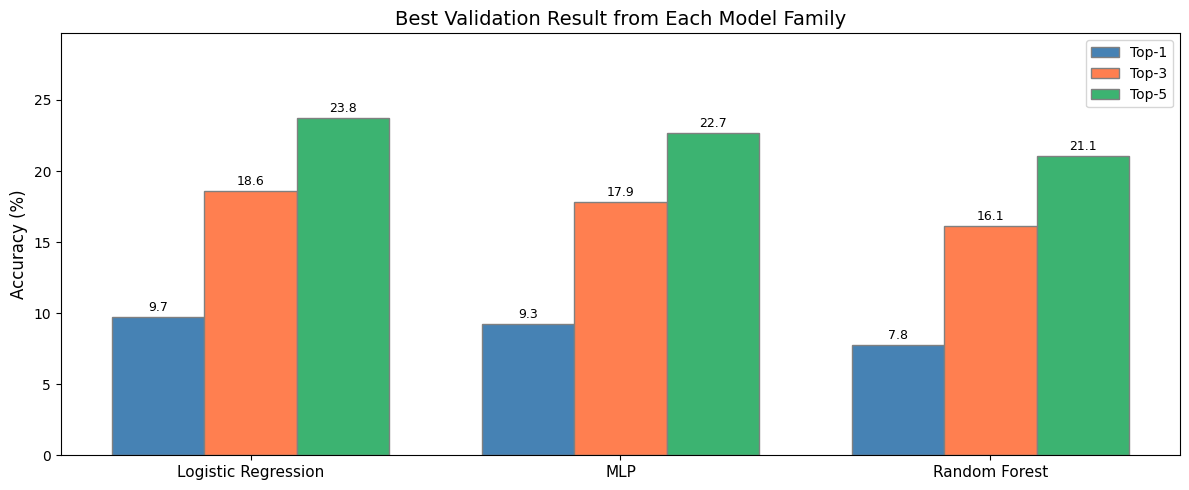

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = validation_summary.copy()
x = np.arange(len(plot_df))
width = 0.25

bars1 = ax.bar(x - width, plot_df['top1_pct'], width, label='Top-1', color='steelblue', edgecolor='grey')
bars2 = ax.bar(x, plot_df['top3_pct'], width, label='Top-3', color='coral', edgecolor='grey')
bars3 = ax.bar(x + width, plot_df['top5_pct'], width, label='Top-5', color='mediumseagreen', edgecolor='grey')

ax.set_title('Best Validation Result from Each Model Family', fontsize=14)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['family'], fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, plot_df['top5_pct'].max() * 1.25)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f'{h:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/final_validation_model_comparison.png', dpi=150)
plt.show()

## Section 10 - Analyze Context Length Effect

This revisits one of the original research questions and checks whether 3, 4, or 5 context words help the best Logistic Regression family.

In [40]:
context_results = []
for ws in [3, 4, 5]:
    dataset = build_split_dataset(window_size=ws, vectorizer_kind=best_lr_feature, vocab_limit=DEFAULT_TOP_N_VOCAB)
    best_for_ws = None
    for alpha in [1e-5, 1e-4]:
        m = SGDClassifier(loss='log_loss', penalty='l2', alpha=alpha,
                          max_iter=30, tol=1e-4, n_iter_no_change=4,
                          random_state=RANDOM_SEED, n_jobs=-1)
        m.fit(dataset['X_train'], dataset['y_train'])
        r = evaluate_probabilistic_model(m, dataset['X_val'], dataset['y_val'],
                                         model_name=f'LR ({best_lr_feature}, w={ws}, a={alpha})')
        r['window_size'] = ws; r['alpha'] = alpha
        if best_for_ws is None or r['top1'] > best_for_ws['top1']:
            best_for_ws = r
    context_results.append(best_for_ws)
    print_eval(best_for_ws, 'Val')
    print(f"  Selected alpha: {best_for_ws['alpha']}\n")

context_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'full_probs']} for r in context_results])
for c in ('top1', 'top3', 'top5'): context_df[c+'_pct'] = (context_df[c]*100).round(2)
context_df[['window_size', 'alpha', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity']].sort_values('window_size')


LR (bow, w=3, a=1e-05) - Val Results
  Top-1 Accuracy    : 0.1048 (10.48%)
  Top-3 Accuracy    : 0.1982 (19.82%)
  Top-5 Accuracy    : 0.2541 (25.41%)
  Cross-Entropy     : 6.3806
  Perplexity        : 590.27
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Selected alpha: 1e-05

LR (bow, w=4, a=1e-05) - Val Results
  Top-1 Accuracy    : 0.0974 (9.74%)
  Top-3 Accuracy    : 0.1900 (19.00%)
  Top-5 Accuracy    : 0.2416 (24.16%)
  Cross-Entropy     : 6.4259
  Perplexity        : 617.66
  Unseen target rate: 7.07%
  N evaluated       : 29,738
  Selected alpha: 1e-05

LR (bow, w=5, a=0.0001) - Val Results
  Top-1 Accuracy    : 0.0916 (9.16%)
  Top-3 Accuracy    : 0.1819 (18.19%)
  Top-5 Accuracy    : 0.2357 (23.57%)
  Cross-Entropy     : 7.1871
  Perplexity        : 1322.26
  Unseen target rate: 7.07%
  N evaluated       : 29,739
  Selected alpha: 0.0001



,window_size,alpha,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity
0,3,0.00001,10.48,19.82,25.41,6.380588,590.274846
1,4,0.00001,9.74,19.00,24.16,6.425934,617.657358
2,5,0.00010,9.16,18.19,23.57,7.187101,1322.264360


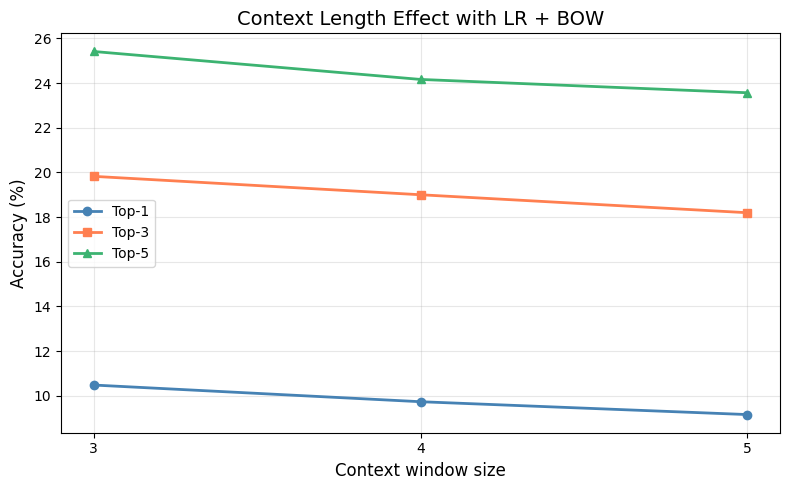

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(context_df['window_size'], context_df['top1'] * 100, 'o-', label='Top-1', color='steelblue', linewidth=2)
ax.plot(context_df['window_size'], context_df['top3'] * 100, 's-', label='Top-3', color='coral', linewidth=2)
ax.plot(context_df['window_size'], context_df['top5'] * 100, '^-', label='Top-5', color='mediumseagreen', linewidth=2)
ax.set_title(f'Context Length Effect with LR + {best_lr_feature.upper()}', fontsize=14)
ax.set_xlabel('Context window size', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xticks([3, 4, 5])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/figures/final_context_length_effect.png', dpi=150)
plt.show()

## Section 11 - Analyze Vocabulary Size Effect

To test whether vocabulary size changes performance in a meaningful way, I compare a few practical vocabulary limits using the strongest Logistic Regression setup.

In [42]:
vocab_results = []

for vocab_limit in [2_000, 5_000, 10_000]:
    dataset = build_split_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind=best_lr_feature, vocab_limit=vocab_limit)
    model = SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=best_lr_alpha,
        max_iter=20,
        tol=1e-3,
        n_iter_no_change=3,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=0,
    )
    model.fit(dataset['X_train'], dataset['y_train'])
    result = evaluate_probabilistic_model(model, dataset['X_val'], dataset['y_val'], model_name=f'LR ({best_lr_feature}, vocab={vocab_limit})')
    result['vocab_limit'] = vocab_limit
    vocab_results.append(result)
    print_eval(result, 'Validation')
    print()

vocab_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'full_probs']} for r in vocab_results])
vocab_df['top1_pct'] = (vocab_df['top1'] * 100).round(2)
vocab_df['top3_pct'] = (vocab_df['top3'] * 100).round(2)
vocab_df['top5_pct'] = (vocab_df['top5'] * 100).round(2)
vocab_df[['vocab_limit', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity']].sort_values('vocab_limit')

LR (bow, vocab=2000) - Validation Results
  Top-1 Accuracy    : 0.0724 (7.24%)
  Top-3 Accuracy    : 0.1555 (15.55%)
  Top-5 Accuracy    : 0.2050 (20.50%)
  Cross-Entropy     : 7.4139
  Perplexity        : 1658.96
  Unseen target rate: 7.07%
  N evaluated       : 29,738

LR (bow, vocab=5000) - Validation Results
  Top-1 Accuracy    : 0.0766 (7.66%)
  Top-3 Accuracy    : 0.1654 (16.54%)
  Top-5 Accuracy    : 0.2154 (21.54%)
  Cross-Entropy     : 7.3828
  Perplexity        : 1608.01
  Unseen target rate: 7.07%
  N evaluated       : 29,738

LR (bow, vocab=10000) - Validation Results
  Top-1 Accuracy    : 0.0972 (9.72%)
  Top-3 Accuracy    : 0.1861 (18.61%)
  Top-5 Accuracy    : 0.2375 (23.75%)
  Cross-Entropy     : 7.2967
  Perplexity        : 1475.43
  Unseen target rate: 7.07%
  N evaluated       : 29,738



,vocab_limit,top1_pct,top3_pct,top5_pct,cross_entropy,perplexity
0,2000,7.24,15.55,20.50,7.413945,1658.958858
1,5000,7.66,16.54,21.54,7.382755,1608.013481
2,10000,9.72,18.61,23.75,7.296706,1475.432065


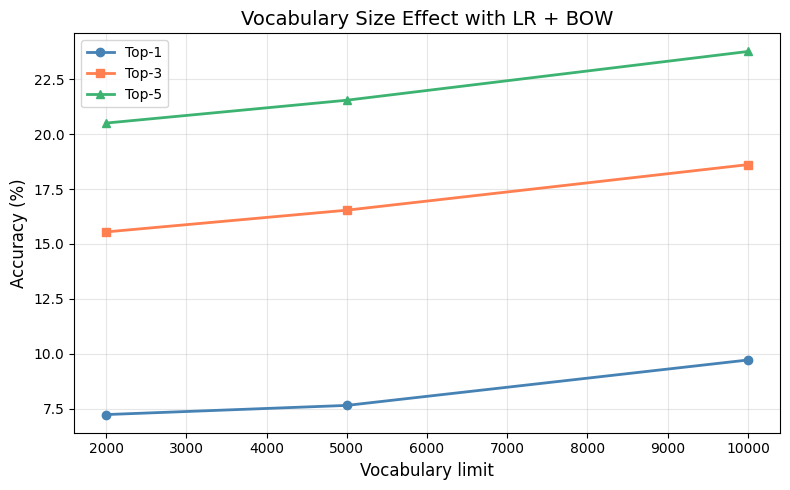

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(vocab_df['vocab_limit'], vocab_df['top1'] * 100, 'o-', label='Top-1', color='steelblue', linewidth=2)
ax.plot(vocab_df['vocab_limit'], vocab_df['top3'] * 100, 's-', label='Top-3', color='coral', linewidth=2)
ax.plot(vocab_df['vocab_limit'], vocab_df['top5'] * 100, '^-', label='Top-5', color='mediumseagreen', linewidth=2)
ax.set_title(f'Vocabulary Size Effect with LR + {best_lr_feature.upper()}', fontsize=14)
ax.set_xlabel('Vocabulary limit', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/figures/final_vocab_size_effect.png', dpi=150)
plt.show()

## Section 12 - Retrain the Best Configurations on Train + Validation

The test set should be touched only once at the end. After choosing hyperparameters on the validation split, I rebuild the **label space** and **feature statistics** on the combined **train + validation** data, retrain each model family on that combined split, and evaluate once on the held-out test books.

In [44]:
from scipy.sparse import vstack as sparse_vstack


def build_final_trainval_dataset(window_size=4, vectorizer_kind='bow', vocab_limit=None, max_samples=200_000):
    contexts, targets, sample_books = generate_samples_for_books(
        cleaned_books, downloaded, window_size, max_samples=max_samples,
    )
    docs = [' '.join(ctx) for ctx in contexts]

    trainval_idx = [i for i, bid in enumerate(sample_books) if bid in train_books or bid in val_books]
    test_idx = [i for i, bid in enumerate(sample_books) if bid in test_books]

    trainval_docs = [docs[i] for i in trainval_idx]
    test_docs = [docs[i] for i in test_idx]
    trainval_targets_raw = [targets[i] for i in trainval_idx]
    test_targets_raw = [targets[i] for i in test_idx]
    trainval_contexts_raw = [contexts[i] for i in trainval_idx]
    test_contexts_raw = [contexts[i] for i in test_idx]

    final_label_encoder = LabelEncoder()
    final_label_encoder.fit(trainval_targets_raw)
    final_class_set = set(final_label_encoder.classes_)
    final_n_classes = len(final_label_encoder.classes_)

    y_trainval = final_label_encoder.transform(trainval_targets_raw)
    y_test = np.full(len(test_targets_raw), -1, dtype=np.int64)
    seen_mask = np.array([t in final_class_set for t in test_targets_raw])
    if seen_mask.any():
        y_test[seen_mask] = final_label_encoder.transform([t for t, m in zip(test_targets_raw, seen_mask) if m])

    if vocab_limit is None:
        vocabulary = list(word2idx.keys())
    else:
        vocab_items = sorted(word2idx.items(), key=lambda kv: kv[1])[:vocab_limit]
        vocabulary = [w for w, _ in vocab_items]
        if '<UNK>' not in vocabulary:
            vocabulary.append('<UNK>')

    vectorizer = make_vectorizer(vocabulary, vectorizer_kind)
    vectorizer.fit(trainval_docs)

    X_trainval = vectorizer.transform(trainval_docs)
    X_test = vectorizer.transform(test_docs)

    return {
        'window_size': window_size,
        'vectorizer_kind': vectorizer_kind,
        'vocab_limit': vocab_limit,
        'vectorizer': vectorizer,
        'label_encoder': final_label_encoder,
        'class_set': final_class_set,
        'n_classes': final_n_classes,
        'X_trainval': X_trainval,
        'X_test': X_test,
        'y_trainval': y_trainval,
        'y_test': y_test,
        'trainval_docs': trainval_docs,
        'test_docs': test_docs,
        'trainval_targets_raw': trainval_targets_raw,
        'test_targets_raw': test_targets_raw,
        'trainval_contexts_raw': trainval_contexts_raw,
        'test_contexts_raw': test_contexts_raw,
    }


def evaluate_with_label_space(model, X, y, n_classes, model_name='Model'):
    probs = model.predict_proba(X)
    full_probs = _expand_proba_to_all_classes(probs, model.classes_, n_classes)
    full_probs = np.clip(full_probs, 1e-15, 1.0)
    full_probs = full_probs / full_probs.sum(axis=1, keepdims=True)

    seen_mask = y >= 0
    unseen_rate = float((~seen_mask).mean())
    y_seen = y[seen_mask]
    fp_seen = full_probs[seen_mask]

    y_pred_seen = np.argmax(fp_seen, axis=1)
    acc_top1 = accuracy_score(y_seen, y_pred_seen)
    k3, k5 = min(3, n_classes), min(5, n_classes)
    top3_cols = np.argpartition(fp_seen, -k3, axis=1)[:, -k3:]
    top5_cols = np.argpartition(fp_seen, -k5, axis=1)[:, -k5:]
    top3_hits = float(np.any(top3_cols == y_seen[:, None], axis=1).mean())
    top5_hits = float(np.any(top5_cols == y_seen[:, None], axis=1).mean())
    ce = log_loss(y_seen, fp_seen, labels=np.arange(n_classes))
    perplexity = float(np.exp(ce))

    y_pred_full = np.full(len(y), -1, dtype=np.int64)
    y_pred_full[seen_mask] = y_pred_seen

    return {
        'model': model_name,
        'top1': float(acc_top1),
        'top3': top3_hits,
        'top5': top5_hits,
        'cross_entropy': float(ce),
        'perplexity': perplexity,
        'unseen_target_rate': unseen_rate,
        'n_evaluated': int(seen_mask.sum()),
        'y_pred': y_pred_full,
        'full_probs': full_probs,
    }


def bootstrap_top1_ci_from_result(result, y, n_boot=BOOTSTRAP_SAMPLES, seed=RANDOM_SEED):
    seen = y >= 0
    correct = (result['y_pred'][seen] == y[seen]).astype(np.float64)
    rng = np.random.RandomState(seed)
    n = len(correct)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        scores[i] = correct[idx].mean()
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def train_final_lr(dataset, alpha):
    model = SGDClassifier(
        loss='log_loss', penalty='l2', alpha=alpha,
        max_iter=50, tol=1e-4, n_iter_no_change=5,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
    )
    model.fit(dataset['X_trainval'], dataset['y_trainval'])
    return model


def train_final_mlp(dataset, alpha):
    model = MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        activation='relu', solver='adam', alpha=alpha,
        batch_size=1024, max_iter=20,
        early_stopping=True, n_iter_no_change=4, validation_fraction=0.1,
        random_state=RANDOM_SEED, verbose=False,
    )
    print('Training final MLP...')
    model.fit(dataset['X_trainval'], dataset['y_trainval'])
    return model


def train_final_rf(dataset, n_estimators, max_depth, min_samples_split, train_subset=FINAL_RF_TRAIN_SUBSET):
    rng = np.random.RandomState(RANDOM_SEED)
    subset_idx = rng.choice(dataset['X_trainval'].shape[0], size=min(train_subset, dataset['X_trainval'].shape[0]), replace=False)
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split,
        max_features='sqrt', random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
    )
    print(f'Training final Random Forest on {len(subset_idx):,} samples...')
    model.fit(dataset['X_trainval'][subset_idx], dataset['y_trainval'][subset_idx])
    return model

In [45]:
final_lr_dataset = build_final_trainval_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind=best_lr_feature, vocab_limit=DEFAULT_TOP_N_VOCAB)
final_mlp_dataset = build_final_trainval_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind=best_mlp_feature, vocab_limit=DEFAULT_TOP_N_VOCAB)
final_rf_dataset = build_final_trainval_dataset(window_size=DEFAULT_WINDOW, vectorizer_kind='tfidf', vocab_limit=DEFAULT_TOP_N_VOCAB)

final_lr_model = train_final_lr(final_lr_dataset, best_lr_alpha)
final_mlp_model = train_final_mlp(final_mlp_dataset, best_mlp_alpha)
final_rf_model = train_final_rf(final_rf_dataset,
                                n_estimators=best_rf_key[0],
                                max_depth=best_rf_key[1],
                                min_samples_split=best_rf_key[2])
print('Final models trained.')
print(f'  LR features  : {best_lr_feature}')
print(f'  MLP features : {best_mlp_feature}')
print(f'  Final label-space size: {final_lr_dataset["n_classes"]:,}')

Training final MLP...
Training final Random Forest on 20,000 samples...
Final models trained.
  LR features  : bow
  MLP features : bow
  Final label-space size: 8,084


## Section 13 - Held-out Test Set Evaluation

In [47]:
SHARED_TEST_SUBSET = min(SHARED_TEST_SUBSET_CAP, final_lr_dataset['X_test'].shape[0])
rng_test = np.random.RandomState(RANDOM_SEED)
shared_test_idx = rng_test.choice(final_lr_dataset['X_test'].shape[0], size=SHARED_TEST_SUBSET, replace=False)
shared_seen_mask = final_lr_dataset['y_test'][shared_test_idx] >= 0


def eval_on_shared(model, dataset, name):
    X = dataset['X_test'][shared_test_idx]
    y = dataset['y_test'][shared_test_idx]
    res = evaluate_with_label_space(model, X, y, dataset['n_classes'], model_name=name)
    lo, hi = bootstrap_top1_ci_from_result(res, y)
    res['top1_ci_lo'] = lo
    res['top1_ci_hi'] = hi
    res['n_total_subset'] = len(y)
    return res


final_lr_test = eval_on_shared(final_lr_model, final_lr_dataset, f'Final LR + {best_lr_feature.upper()}')
final_mlp_test = eval_on_shared(final_mlp_model, final_mlp_dataset, f'Final MLP ({best_mlp_feature})')
final_rf_test = eval_on_shared(final_rf_model, final_rf_dataset, 'Final Random Forest')

# Build fair baselines from TRAIN+VAL only, then evaluate on the same seen-target rows.
trainval_targets_final = final_lr_dataset['trainval_targets_raw']
trainval_contexts_final = final_lr_dataset['trainval_contexts_raw']
unigram_counts_final = Counter(trainval_targets_final)
unigram_ranked_final = [w for w, _ in unigram_counts_final.most_common()]

bigram_counts_final = defaultdict(Counter)
for ctx, tgt in zip(trainval_contexts_final, trainval_targets_final):
    bigram_counts_final[ctx[-1]][tgt] += 1
bigram_ranked_final = {prev: [w for w, _ in counts.most_common()] for prev, counts in bigram_counts_final.items()}


def final_bigram_topk(prev_word, k):
    if prev_word in bigram_ranked_final and bigram_ranked_final[prev_word]:
        ranked = bigram_ranked_final[prev_word]
        if len(ranked) >= k:
            return ranked[:k]
        out = list(ranked)
        for w in unigram_ranked_final:
            if w not in out:
                out.append(w)
                if len(out) == k:
                    break
        return out
    return unigram_ranked_final[:k]


def topk_accuracy_strings(pred_lists, truths):
    return sum(1 for preds, truth in zip(pred_lists, truths) if truth in preds) / max(1, len(truths))


def eval_final_unigram(truths):
    top1_word = unigram_ranked_final[0]
    top1 = sum(1 for t in truths if t == top1_word) / max(1, len(truths))
    top3_preds = [unigram_ranked_final[:3]] * len(truths)
    top5_preds = [unigram_ranked_final[:5]] * len(truths)
    return {
        'top1': top1,
        'top3': topk_accuracy_strings(top3_preds, truths),
        'top5': topk_accuracy_strings(top5_preds, truths),
    }


def eval_final_bigram(contexts, truths):
    top1_preds = [final_bigram_topk(c[-1], 1)[0] for c in contexts]
    top3_preds = [final_bigram_topk(c[-1], 3) for c in contexts]
    top5_preds = [final_bigram_topk(c[-1], 5) for c in contexts]
    return {
        'top1': sum(1 for p, t in zip(top1_preds, truths) if p == t) / max(1, len(truths)),
        'top3': topk_accuracy_strings(top3_preds, truths),
        'top5': topk_accuracy_strings(top5_preds, truths),
    }


shared_test_targets = [final_lr_dataset['test_targets_raw'][i] for i in shared_test_idx]
shared_test_contexts = [final_lr_dataset['test_contexts_raw'][i] for i in shared_test_idx]
shared_seen_targets = [t for t, keep in zip(shared_test_targets, shared_seen_mask) if keep]
shared_seen_contexts = [c for c, keep in zip(shared_test_contexts, shared_seen_mask) if keep]

uni_test_shared = eval_final_unigram(shared_seen_targets)
bi_test_shared = eval_final_bigram(shared_seen_contexts, shared_seen_targets)

print_eval(final_lr_test, 'Test (shared subset)')
print(f"  Top-1 95% CI      : [{final_lr_test['top1_ci_lo']*100:.2f}%, {final_lr_test['top1_ci_hi']*100:.2f}%]")
print()
print_eval(final_mlp_test, 'Test (shared subset)')
print(f"  Top-1 95% CI      : [{final_mlp_test['top1_ci_lo']*100:.2f}%, {final_mlp_test['top1_ci_hi']*100:.2f}%]")
print()
print_eval(final_rf_test, 'Test (shared subset)')
print(f"  Top-1 95% CI      : [{final_rf_test['top1_ci_lo']*100:.2f}%, {final_rf_test['top1_ci_hi']*100:.2f}%]")
print()
print('Baselines below are evaluated on the same shared subset and the same seen-target rows as the trained models.')
print(f"Unigram baseline   - Top1: {uni_test_shared['top1']*100:.2f}%, Top3: {uni_test_shared['top3']*100:.2f}%, Top5: {uni_test_shared['top5']*100:.2f}%")
print(f"Bigram   baseline  - Top1: {bi_test_shared['top1']*100:.2f}%, Top3: {bi_test_shared['top3']*100:.2f}%, Top5: {bi_test_shared['top5']*100:.2f}%")

Final LR + BOW - Test (shared subset) Results
  Top-1 Accuracy    : 0.0990 (9.90%)
  Top-3 Accuracy    : 0.1956 (19.56%)
  Top-5 Accuracy    : 0.2548 (25.48%)
  Cross-Entropy     : 7.6053
  Perplexity        : 2008.79
  Unseen target rate: 2.00%
  N evaluated       : 2,940
  Top-1 95% CI      : [8.89%, 11.00%]

Final MLP (bow) - Test (shared subset) Results
  Top-1 Accuracy    : 0.0997 (9.97%)
  Top-3 Accuracy    : 0.1738 (17.38%)
  Top-5 Accuracy    : 0.2201 (22.01%)
  Cross-Entropy     : 6.6742
  Perplexity        : 791.70
  Unseen target rate: 2.00%
  N evaluated       : 2,940
  Top-1 95% CI      : [8.95%, 11.12%]

Final Random Forest - Test (shared subset) Results
  Top-1 Accuracy    : 0.0731 (7.31%)
  Top-3 Accuracy    : 0.1466 (14.66%)
  Top-5 Accuracy    : 0.1959 (19.59%)
  Cross-Entropy     : 8.4714
  Perplexity        : 4776.04
  Unseen target rate: 2.00%
  N evaluated       : 2,940
  Top-1 95% CI      : [6.43%, 8.31%]

Baselines below are evaluated on the same shared subset a

In [48]:
test_rows = []
for r, fam in [(final_lr_test, 'Logistic Regression'),
               (final_mlp_test, 'MLP'),
               (final_rf_test, 'Random Forest')]:
    test_rows.append({
        'family': fam,
        'model': r['model'],
        'top1': r['top1'], 'top3': r['top3'], 'top5': r['top5'],
        'top1_ci_lo': r['top1_ci_lo'], 'top1_ci_hi': r['top1_ci_hi'],
        'cross_entropy': r['cross_entropy'], 'perplexity': r['perplexity'],
        'unseen_target_rate': r['unseen_target_rate'],
        'n_evaluated': r['n_evaluated'],
    })
for name, res in [('Unigram baseline', uni_test_shared), ('Bigram baseline', bi_test_shared)]:
    test_rows.append({
        'family': name, 'model': name,
        'top1': res['top1'], 'top3': res['top3'], 'top5': res['top5'],
        'top1_ci_lo': float('nan'), 'top1_ci_hi': float('nan'),
        'cross_entropy': float('nan'), 'perplexity': float('nan'),
        'unseen_target_rate': float('nan'),
        'n_evaluated': int(shared_seen_mask.sum()),
    })

test_summary = pd.DataFrame(test_rows)
for c in ('top1', 'top3', 'top5'):
    test_summary[c + '_pct'] = (test_summary[c] * 100).round(2)
test_summary['top1_ci'] = test_summary.apply(
    lambda r: f"[{r['top1_ci_lo']*100:.2f}, {r['top1_ci_hi']*100:.2f}]" if pd.notna(r['top1_ci_lo']) else '—',
    axis=1,
)
test_summary[['family', 'top1_pct', 'top1_ci', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity', 'unseen_target_rate', 'n_evaluated']].sort_values('top1_pct', ascending=False)

,family,top1_pct,top1_ci,top3_pct,top5_pct,cross_entropy,perplexity,unseen_target_rate,n_evaluated
4,Bigram baseline,11.70,—,23.13,28.06,NaN,NaN,NaN,2940
1,MLP,9.97,"[8.95, 11.12]",17.38,22.01,6.674188,791.703976,0.02,2940
0,Logistic Regression,9.90,"[8.89, 11.00]",19.56,25.48,7.605288,2008.790236,0.02,2940
2,Random Forest,7.31,"[6.43, 8.31]",14.66,19.59,8.471367,4776.037896,0.02,2940
3,Unigram baseline,5.88,—,12.55,17.86,NaN,NaN,NaN,2940


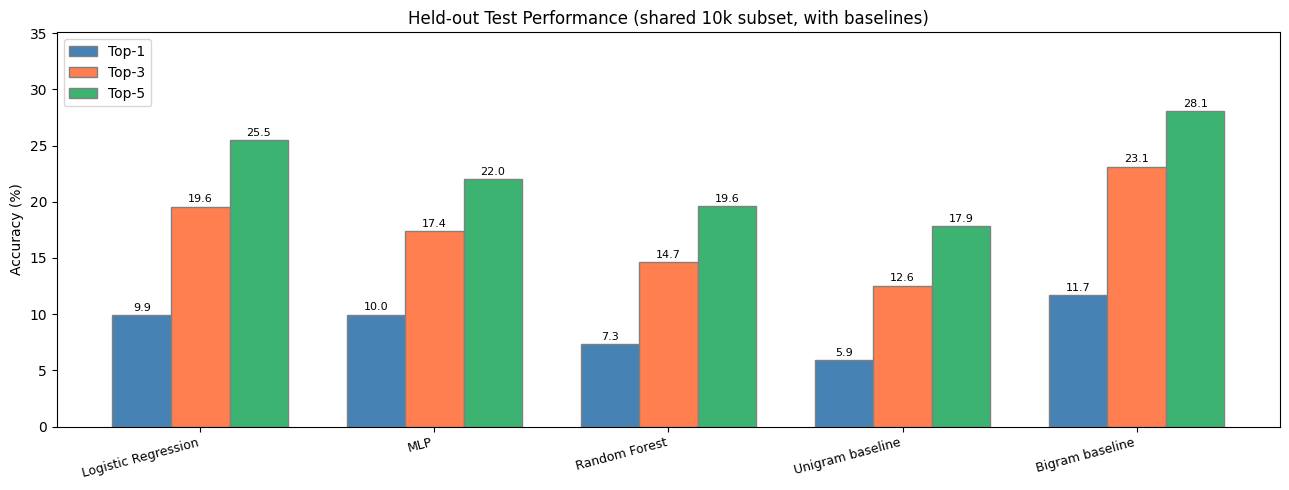

In [49]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_df = test_summary.copy()
x = np.arange(len(plot_df)); width = 0.25

ax.bar(x - width, plot_df['top1_pct'], width, label='Top-1', color='steelblue', edgecolor='grey')
ax.bar(x,         plot_df['top3_pct'], width, label='Top-3', color='coral', edgecolor='grey')
ax.bar(x + width, plot_df['top5_pct'], width, label='Top-5', color='mediumseagreen', edgecolor='grey')
ax.set_title('Held-out Test Performance (shared 10k subset, with baselines)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x); ax.set_xticklabels(plot_df['family'], fontsize=9, rotation=15, ha='right')
ax.legend(); ax.set_ylim(0, max(1.0, plot_df['top5_pct'].max()*1.25))
for c, off in [('top1_pct', -width), ('top3_pct', 0), ('top5_pct', width)]:
    for xi, h in zip(x + off, plot_df[c]):
        ax.text(xi, h + 0.2, f'{h:.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/figures/final_test_model_comparison.png', dpi=150)
plt.show()


## Section 14 - Error Analysis for the Best Final Model

This section focuses on the strongest final model on the held-out test set and asks which words are most frequently mispredicted.

In [50]:
model_only_summary = test_summary[test_summary['family'].isin(['Logistic Regression', 'MLP', 'Random Forest'])].copy()
best_final_row = model_only_summary.sort_values(['top1', 'top5'], ascending=False).iloc[0]
best_family = best_final_row['family']

if best_family == 'Logistic Regression':
    best_test_result = final_lr_test
    best_test_dataset = final_lr_dataset
elif best_family == 'MLP':
    best_test_result = final_mlp_test
    best_test_dataset = final_mlp_dataset
else:
    best_test_result = final_rf_test
    best_test_dataset = final_rf_dataset

print('Best trained model family:', best_family)
print(best_final_row[['family', 'model', 'top1_pct', 'top3_pct', 'top5_pct', 'cross_entropy', 'perplexity']])

Best trained model family: MLP
family                       MLP
model            Final MLP (bow)
top1_pct                    9.97
top3_pct                   17.38
top5_pct                   22.01
cross_entropy           6.674188
perplexity            791.703976
Name: 1, dtype: object


In [51]:
y_true_best = best_test_dataset['y_test'][shared_test_idx]
test_docs_best = [best_test_dataset['test_docs'][i] for i in shared_test_idx]
y_pred_best = best_test_result['y_pred']
label_enc_best = best_test_dataset['label_encoder']

seen = y_true_best >= 0
y_true_seen = y_true_best[seen]
y_pred_seen = y_pred_best[seen]
docs_seen = [d for d, s in zip(test_docs_best, seen) if s]
error_mask = y_pred_seen != y_true_seen

error_df = pd.DataFrame({
    'context': [d for d, e in zip(docs_seen, error_mask) if e],
    'true_word': label_enc_best.inverse_transform(y_true_seen[error_mask]),
    'pred_word': label_enc_best.inverse_transform(y_pred_seen[error_mask]),
})
print(f'Evaluated: {len(y_true_seen):,}  Errors: {error_mask.sum():,}')
error_df.head(10)

Evaluated: 2,940  Errors: 2,647


,context,true_word,pred_word
0,i remember her bringing,me,a
1,hidden from me before,a,the
2,face in a glass,the,of
3,not merely that i,paint,have
4,their lives they shall,on,be
5,a stirring i set,still,man
6,much longer then for,an,the
7,widow <UNK> is all,told,the
8,a way that was,hidden,to
9,born of parents in,effect,the


In [52]:
most_mispredicted = error_df['true_word'].value_counts().head(15).reset_index()
most_mispredicted.columns = ['true_word', 'error_count']
most_mispredicted

,true_word,error_count
0,the,82
1,a,70
2,and,70
3,in,63
4,to,51
5,of,49
6,it,43
7,i,40
8,that,32
9,was,31


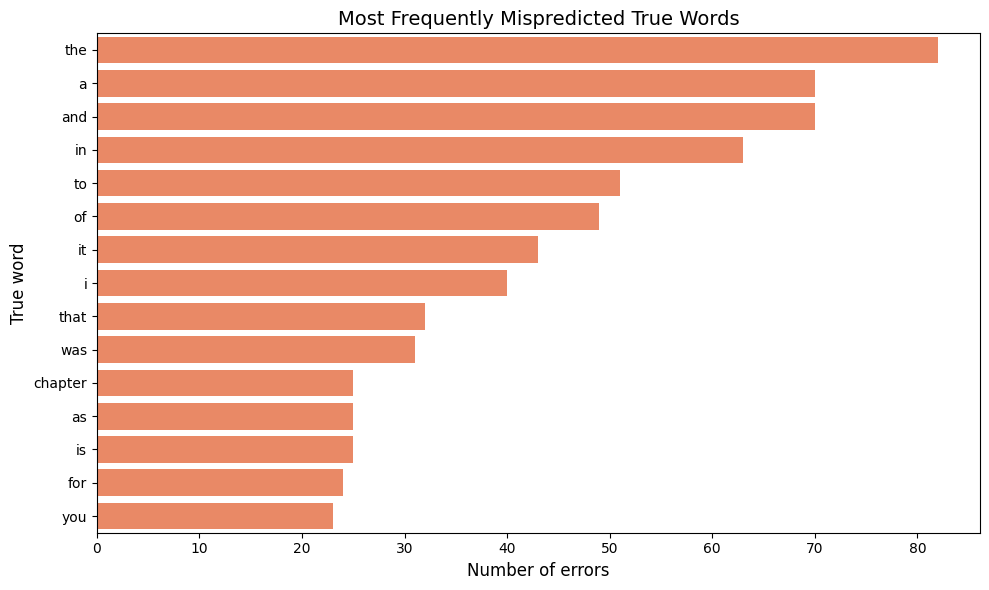

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=most_mispredicted, y='true_word', x='error_count', color='coral', ax=ax)
ax.set_title('Most Frequently Mispredicted True Words', fontsize=14)
ax.set_xlabel('Number of errors', fontsize=12)
ax.set_ylabel('True word', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/final_mispredicted_words.png', dpi=150)
plt.show()

In [54]:
common = pd.Series(label_enc_best.inverse_transform(y_true_seen)).value_counts().head(15).index.tolist()
filtered = error_df[error_df['true_word'].isin(common)]
confusion_pairs = filtered.groupby(['true_word', 'pred_word']).size().reset_index(name='count').sort_values('count', ascending=False).head(20)
confusion_pairs

,true_word,pred_word,count
8,a,the,42
24,and,the,28
100,of,the,22
123,the,of,21
115,the,and,20
138,to,the,18
21,and,of,16
68,in,the,16
89,it,the,15
59,in,and,14
